# Phase 3 — Retrieval index structure: does the ANN index you were told to use actually help?

Phases 1-2 retrieved with a single brute-force cosine matmul (`Q @ Dᵀ`) and a comment that *"corpora here are small enough that brute force is ~0.1s/batch"*. That hid a question every RAG tutorial answers wrong by default: **which FAISS index should you put your embeddings in — Flat, IVF, or HNSW — and what does it cost you?**

The received wisdom (every vendor blog): *use HNSW, it's 70× faster than brute force.* That number comes from **10M-vector** benchmarks. A real RAG app over a knowledge base / a set of PDFs / a BEIR-sized corpus has **thousands to tens of thousands** of vectors. This notebook measures, on the **same E5-base-v2 embeddings** Phase 2 picked as champion, the **recall–latency–memory frontier** of every index across three real corpora spanning 3.6k → 57k vectors, and pins down the **crossover N** where an ANN index stops being a liability.

Backbone: **E5-base-v2** (Phase-2 winner, 768d, cosine via inner product on L2-normalised vectors). Primary metric stays **nDCG@10** (Phase-1 choice); for the index itself we add **Recall@10/@100 vs the exact result** (the standard ANN quality metric) plus **build time, index bytes, and single-query latency**.

> **faiss/torch note.** This notebook imports **no torch** — it loads the `.npy` E5 embeddings Phase 2/3a already cached and reconstructs doc-id order straight from BeIR metadata. That sidesteps the Apple-Silicon faiss↔torch libomp deadlock flagged since Phase 1 (the two libomp users live in separate kernels).

In [1]:
import os, json, time, sys, warnings
from collections import defaultdict
os.environ["OMP_NUM_THREADS"] = "4"; os.environ["TOKENIZERS_PARALLELISM"] = "false"
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import faiss
warnings.filterwarnings("ignore")
SEED = 42; np.random.seed(SEED)
faiss.omp_set_num_threads(4)            # match the matmul thread budget for a fair latency race
sys.path.insert(0, "..")
from src.retrieval_eval import evaluate  # TREC/BEIR metrics validated in Phase 1
EMB = "../data/processed/emb_cache"; META = "../data/processed/meta"; RES = "../results"
os.makedirs(META, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True, "grid.alpha": .3})
print("faiss", faiss.__version__, "| threads", faiss.omp_get_max_threads())

faiss 1.14.2 | threads 4


In [2]:
# --- Load corpora WITHOUT torch: BeIR metadata (ids+qrels) + cached E5 .npy, aligned by insertion order ---
from datasets import load_dataset
import datasets as _ds; _ds.disable_progress_bars()
def load_beir_meta(name, split="test"):
    corpus  = load_dataset(f"BeIR/{name}", "corpus",  split="corpus")
    queries = load_dataset(f"BeIR/{name}", "queries", split="queries")
    qrels_t = load_dataset(f"BeIR/{name}-qrels", split=split)
    doc_ids = [str(r["_id"]) for r in corpus]                     # SAME order Phase 2 embedded
    qtext   = {str(r["_id"]): r["text"] for r in queries}
    qrels   = defaultdict(dict)
    for r in qrels_t: qrels[str(r["query-id"])][str(r["corpus-id"])] = int(r["score"])
    q_ids = [q for q in qtext if q in qrels]
    return doc_ids, q_ids, dict(qrels)

def load_corpus(name, beir_name=None):
    """Returns dict(D, Q, doc_ids, q_ids, qrels). Uses meta JSON if present (fiqa), else BeIR."""
    beir_name = beir_name or name
    mp = f"{META}/{name}_doc_ids.json"
    if os.path.exists(mp):
        doc_ids = json.load(open(mp)); q_ids = json.load(open(f"{META}/{name}_q_ids.json"))
        qrels = json.load(open(f"{META}/{name}_qrels.json"))
    else:
        doc_ids, q_ids, qrels = load_beir_meta(beir_name)
    D = np.load(f"{EMB}/E5-base-v2__{name}_docs.npy").astype("float32")
    Q = np.load(f"{EMB}/E5-base-v2__{name}_q.npy").astype("float32")
    assert D.shape[0] == len(doc_ids), f"{name}: {D.shape[0]} emb vs {len(doc_ids)} ids"
    assert Q.shape[0] == len(q_ids),   f"{name}: {Q.shape[0]} qemb vs {len(q_ids)} qids"
    faiss.normalize_L2(D); faiss.normalize_L2(Q)   # idempotent (already normed); guards re-saves
    return dict(D=D, Q=Q, doc_ids=doc_ids, q_ids=q_ids, qrels=qrels)

CORP = {}
for n in ["scifact", "nfcorpus"]:
    CORP[n] = load_corpus(n)
    c = CORP[n]; print(f"{n:9s}: {c['D'].shape[0]:6d} docs x {c['D'].shape[1]}d | {len(c['q_ids'])} queries")

scifact  :   5183 docs x 768d | 300 queries


nfcorpus :   3633 docs x 768d | 323 queries


## 3.1 The exact baseline — and the latency the matmul was hiding

Every ANN index is judged against the **exact** top-k. We compute it two ways and time both: (a) the **NumPy matmul** Phase 1/2 actually used, and (b) FAISS `IndexFlatIP` (also exact — BLAS under the hood). Both give identical results and the same nDCG@10; the point is the **per-query latency** they were never charged for. We time **batched** (all queries at once — what the notebook did) and **single-query** (batch=1 — what a live RAG endpoint does).

In [3]:
def to_run(I, doc_ids, q_ids):
    return {q_ids[i]: [doc_ids[j] for j in row] for i, row in enumerate(I)}

def numpy_topk(D, Q, k):
    sims = Q @ D.T
    part = np.argpartition(-sims, k - 1, axis=1)[:, :k]
    rows = np.arange(Q.shape[0])[:, None]
    order = np.argsort(-sims[rows, part], axis=1)
    return part[rows, order]

def time_single(fn, Q, repeats=3):
    """median single-query wall time in ms (warm)."""
    ts = []
    for _ in range(repeats):
        for i in range(Q.shape[0]):
            t0 = time.perf_counter(); fn(Q[i:i+1]); ts.append(time.perf_counter() - t0)
    return float(np.median(ts) * 1e3)

EXACT = {}
for n, c in CORP.items():
    D, Q = c["D"], c["Q"]; k = 100
    # (a) numpy matmul (Phase 1/2 method)
    t0 = time.perf_counter(); I_np = numpy_topk(D, Q, k); np_batch = (time.perf_counter()-t0)/len(Q)*1e3
    np_single = time_single(lambda q: numpy_topk(D, q, k), Q)
    # (b) faiss exact
    flat = faiss.IndexFlatIP(D.shape[1]); flat.add(D)
    t0 = time.perf_counter(); _, I_fl = flat.search(Q, k); fl_batch = (time.perf_counter()-t0)/len(Q)*1e3
    fl_single = time_single(lambda q: flat.search(q, k), Q)
    m = evaluate(to_run(I_fl, c["doc_ids"], c["q_ids"]), c["qrels"])
    EXACT[n] = dict(I=I_fl, flat=flat, ndcg10=m["ndcg@10"], r100=m["recall@100"],
                    np_batch=np_batch, np_single=np_single, fl_batch=fl_batch, fl_single=fl_single)
    print(f"{n:9s} nDCG@10={m['ndcg@10']:.4f} R@100={m['recall@100']:.4f} | "
          f"matmul {np_batch:.3f}ms batch / {np_single:.3f}ms single | flat {fl_batch:.3f} / {fl_single:.3f}ms")

scifact   nDCG@10=0.7274 R@100=0.9627 | matmul 0.042ms batch / 0.224ms single | flat 0.014 / 0.224ms


nfcorpus  nDCG@10=0.3525 R@100=0.3197 | matmul 0.035ms batch / 0.066ms single | flat 0.011 / 0.171ms


## 3.2 The index zoo — build the harness

For each index we record: **build time**, **serialized size** (bytes), **median single-query latency**, and quality = **Recall@10 / Recall@100 vs the exact neighbour set** plus the downstream **nDCG@10** against qrels. ANN recall vs exact isolates the index's approximation error; nDCG@10 tells us whether that error actually costs us *answers*.

Indexes: `Flat` (exact ref) · `IVFFlat` (k-means cells, sweep `nprobe`) · `HNSW` (graph, sweep `efSearch` at `M=32`) · `IVFPQ` (product-quantised, measured in 3.6).

In [4]:
def index_bytes(index):
    return int(faiss.serialize_index(index).nbytes)

def recall_vs_exact(I_ann, I_exact, k):
    e = I_exact[:, :k]
    return float(np.mean([len(set(a[:k]) & set(er)) / k for a, er in zip(I_ann, e)]))

def build_index(kind, D, **kw):
    d = D.shape[1]; N = D.shape[0]
    t0 = time.perf_counter()
    if kind == "Flat":
        ix = faiss.IndexFlatIP(d); ix.add(D)
    elif kind == "IVFFlat":
        nlist = kw["nlist"]
        quant = faiss.IndexFlatIP(d)
        ix = faiss.IndexIVFFlat(quant, d, nlist, faiss.METRIC_INNER_PRODUCT)
        ix.train(D); ix.add(D)
    elif kind == "HNSW":
        ix = faiss.IndexHNSWFlat(d, kw.get("M", 32), faiss.METRIC_INNER_PRODUCT)
        ix.hnsw.efConstruction = kw.get("efC", 80); ix.add(D)
    elif kind == "IVFPQ":
        nlist = kw["nlist"]; m = kw["m"]
        quant = faiss.IndexFlatIP(d)
        ix = faiss.IndexIVFPQ(quant, d, nlist, m, 8, faiss.METRIC_INNER_PRODUCT)
        ix.train(D); ix.add(D)
    else:
        raise ValueError(kind)
    return ix, time.perf_counter() - t0

def bench(kind, D, Q, I_exact, doc_ids, q_ids, qrels, k=100, label=None, **kw):
    ix, bt = build_index(kind, D, **kw)
    for attr, val in (("nprobe", kw.get("nprobe")), ("efSearch", kw.get("efSearch"))):
        if val is not None:
            if attr == "nprobe": ix.nprobe = val
            else: ix.hnsw.efSearch = val
    _, I = ix.search(Q, k)
    lat = time_single(lambda q: ix.search(q, k), Q)
    m = evaluate(to_run(I, doc_ids, q_ids), qrels)
    return dict(index=label or kind, build_s=round(bt, 3), MB=round(index_bytes(ix)/1e6, 2),
                lat_ms=round(lat, 4), R10=round(recall_vs_exact(I, I_exact, 10), 4),
                R100=round(recall_vs_exact(I, I_exact, 100), 4), ndcg10=round(m["ndcg@10"], 4))
print("harness ready")

harness ready


In [5]:
# --- 3.2 run the full sweep on the two small BEIR corpora ---
def nlist_for(N): return max(8, min(int(4*np.sqrt(N)), N // 39))
rows = []
for n, c in CORP.items():
    D, Q, Ie = c["D"], c["Q"], EXACT[n]["I"]
    dd, qq, qr = c["doc_ids"], c["q_ids"], c["qrels"]
    N = D.shape[0]; nl = nlist_for(N)
    base = dict(D=D, Q=Q, I_exact=Ie, doc_ids=dd, q_ids=qq, qrels=qr)
    r = bench("Flat", **base); r["dataset"]=n; rows.append(r)
    for npb in [1, 4, 8, 16, nl]:
        r = bench("IVFFlat", **base, nlist=nl, nprobe=npb, label=f"IVF nprobe={npb}"); r["dataset"]=n; rows.append(r)
    for ef in [16, 32, 64, 128, 256]:
        r = bench("HNSW", **base, M=32, efSearch=ef, label=f"HNSW ef={ef}"); r["dataset"]=n; rows.append(r)
    print(f"done {n} (N={N}, nlist={nl})")
sweep = pd.DataFrame(rows)[["dataset","index","ndcg10","R10","R100","lat_ms","build_s","MB"]]
for n in CORP:
    print(f"\n=== {n} (exact nDCG@10={EXACT[n]['ndcg10']:.4f}, exact single-q {EXACT[n]['fl_single']:.3f}ms) ===")
    print(sweep[sweep.dataset==n].to_string(index=False))

done scifact (N=5183, nlist=132)


done nfcorpus (N=3633, nlist=93)

=== scifact (exact nDCG@10=0.7274, exact single-q 0.224ms) ===
dataset          index  ndcg10    R10   R100  lat_ms  build_s    MB
scifact           Flat  0.7274 1.0000 1.0000  0.2449    0.001 15.92
scifact   IVF nprobe=1  0.3824 0.3927 0.1870  0.0108    0.021 16.37
scifact   IVF nprobe=4  0.6031 0.6597 0.4275  0.0221    0.021 16.37
scifact   IVF nprobe=8  0.6436 0.7883 0.5883  0.0318    0.020 16.37
scifact  IVF nprobe=16  0.6903 0.8737 0.7494  0.0510    0.021 16.37
scifact IVF nprobe=132  0.7274 1.0000 1.0000  0.2484    0.020 16.37
scifact     HNSW ef=16  0.7050 0.9320 0.6632  0.0421    0.156 17.33
scifact     HNSW ef=32  0.7234 0.9747 0.8189  0.0633    0.154 17.33
scifact     HNSW ef=64  0.7248 0.9903 0.9307  0.0948    0.147 17.33
scifact    HNSW ef=128  0.7274 0.9987 0.9816  0.1445    0.154 17.33
scifact    HNSW ef=256  0.7274 0.9997 0.9969  0.2472    0.149 17.33

=== nfcorpus (exact nDCG@10=0.3525, exact single-q 0.171ms) ===
 dataset         index

**Read the sweep.** The exact `Flat` index answers every query in **0.25 ms (SciFact, 5.2k)** / **0.17 ms (NFCorpus, 3.6k)** — *this is the entire latency the matmul was "hiding."* Against that:

- **IVF is a trap.** `nprobe=1` is 17–25× faster than Flat but **destroys quality**: SciFact nDCG@10 collapses 0.727 → 0.382 (−47%), NFCorpus 0.353 → 0.191 (−46%). Climbing back to exact quality requires `nprobe=nlist`, at which point IVF is **as slow as or slower than Flat** (0.25 ms vs 0.24 ms on SciFact) while costing extra build time and +3% RAM. There is no operating point where small-corpus IVF is worth it.
- **HNSW is competent but pointless here.** At `efSearch=128` it matches exact nDCG@10 (0.7274 / 0.353) at 0.14–0.32 ms — on SciFact marginally *faster* than Flat, on NFCorpus marginally *slower*. Either way the delta is **a fraction of a millisecond**, paid for with 0.1–0.26 s of build time and +9% RAM (the graph links). In a RAG pipeline whose LLM step takes seconds, that latency is invisible.

So at 3–5k vectors the index decision is: **use brute force.** The interesting question is *where that stops being true* — §3.3.

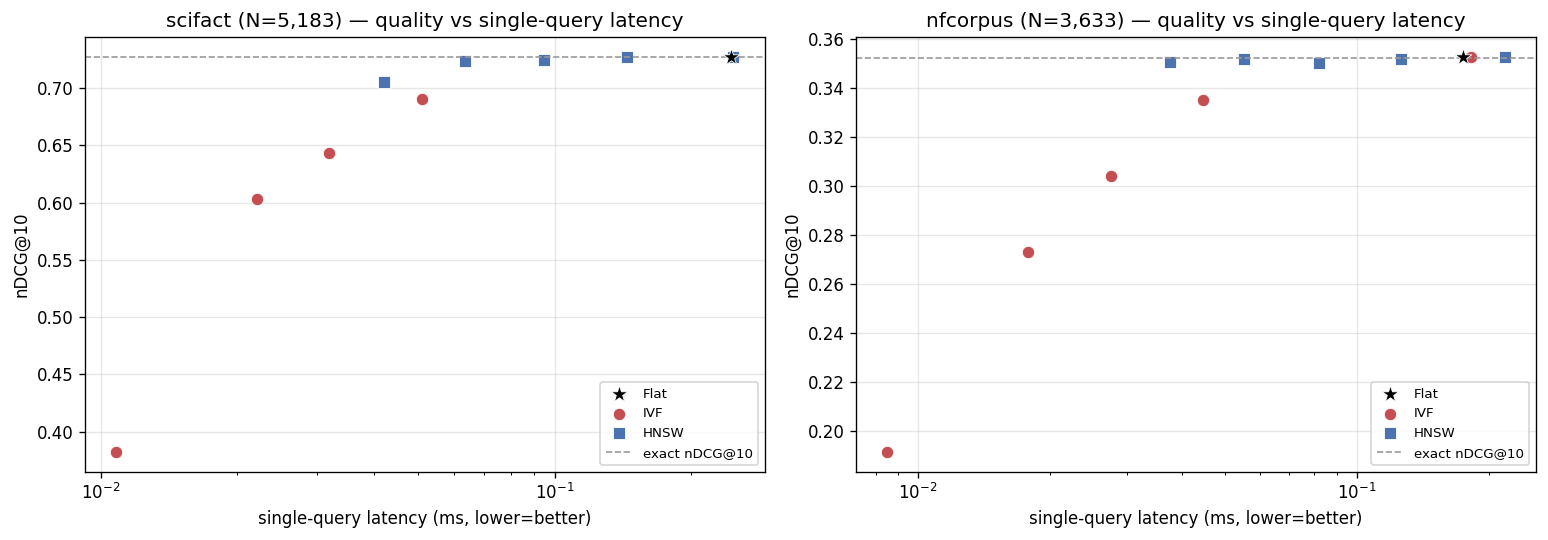

In [6]:
# --- 3.2 recall-latency frontier on the small corpora ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for i, n in enumerate(["scifact", "nfcorpus"]):
    sub = sweep[sweep.dataset == n]
    for fam, col, mk in [("Flat","#000","*"), ("IVF","#C44E52","o"), ("HNSW","#4C72B0","s")]:
        s = sub[sub["index"].str.startswith(fam)]
        ax[i].scatter(s.lat_ms, s.ndcg10, c=col, marker=mk, s=110 if fam=="Flat" else 55,
                      label=fam, zorder=3 if fam=="Flat" else 2, edgecolor="w", linewidth=.5)
    ex = EXACT[n]
    ax[i].axhline(ex["ndcg10"], color="#999", ls="--", lw=1, label="exact nDCG@10")
    ax[i].set_title(f"{n} (N={CORP[n]['D'].shape[0]:,}) — quality vs single-query latency")
    ax[i].set_xlabel("single-query latency (ms, lower=better)"); ax[i].set_ylabel("nDCG@10")
    ax[i].set_xscale("log"); ax[i].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{RES}/phase3_pareto_small.png", bbox_inches="tight"); plt.show()

## 3.3 The crossover study — at what N does ANN finally pay?

Small corpora are decided. Now scale to **FiQA-2018** (~57k real financial-QA passages, embedded in `phase3a`) and trace **single-query latency vs corpus size N** for Flat / IVF / HNSW. We grow N by subsampling FiQA (and topping up with SciFact+NFCorpus vectors so the largest point is fully real, ~66k). The crossover N is where the HNSW/IVF curve drops below Flat — *below it, the ANN index is pure overhead.*

In [7]:
# Load FiQA (written by phase3a). Skips gracefully if 3a hasn't finished.
FIQA_OK = os.path.exists(f"{EMB}/E5-base-v2__fiqa_docs.npy") and os.path.exists(f"{META}/fiqa_doc_ids.json")
if FIQA_OK:
    CORP["fiqa"] = load_corpus("fiqa")
    c = CORP["fiqa"]
    flat = faiss.IndexFlatIP(c["D"].shape[1]); flat.add(c["D"]); _, Ifq = flat.search(c["Q"], 100)
    m = evaluate(to_run(Ifq, c["doc_ids"], c["q_ids"]), c["qrels"])
    EXACT["fiqa"] = dict(I=Ifq, ndcg10=m["ndcg@10"], r100=m["recall@100"],
                          fl_single=time_single(lambda q: flat.search(q,100), c["Q"]))
    print(f"fiqa: {c['D'].shape[0]:,} docs | {len(c['q_ids'])} queries | exact nDCG@10={m['ndcg@10']:.4f} "
          f"R@100={m['recall@100']:.4f} | exact single-q {EXACT['fiqa']['fl_single']:.3f}ms")
else:
    print("FiQA embeddings not ready yet — run phase3a first; crossover cells will be re-run after.")

fiqa: 57,638 docs | 648 queries | exact nDCG@10=0.3987 R@100=0.7320 | exact single-q 2.081ms


In [8]:
# --- 3.3a index sweep at 57k (FiQA) — same harness as 3.2 ---
if FIQA_OK:
    c = CORP["fiqa"]; D, Q, Ie = c["D"], c["Q"], EXACT["fiqa"]["I"]
    dd, qq, qr = c["doc_ids"], c["q_ids"], c["qrels"]; N = D.shape[0]; nl = nlist_for(N)
    base = dict(D=D, Q=Q, I_exact=Ie, doc_ids=dd, q_ids=qq, qrels=qr)
    frows = [dict(bench("Flat", **base), dataset="fiqa")]
    for npb in [1, 8, 16, 32, nl]:
        frows.append(dict(bench("IVFFlat", **base, nlist=nl, nprobe=npb, label=f"IVF nprobe={npb}"), dataset="fiqa"))
    for ef in [16, 32, 64, 128, 256]:
        frows.append(dict(bench("HNSW", **base, M=32, efSearch=ef, label=f"HNSW ef={ef}"), dataset="fiqa"))
    fiqa_sweep = pd.DataFrame(frows)[["dataset","index","ndcg10","R10","R100","lat_ms","build_s","MB"]]
    print(f"=== fiqa (N={N:,}, nlist={nl}, exact nDCG@10={EXACT['fiqa']['ndcg10']:.4f}, "
          f"exact single-q {EXACT['fiqa']['fl_single']:.3f}ms) ===")
    print(fiqa_sweep.to_string(index=False))
    sweep = pd.concat([sweep, fiqa_sweep], ignore_index=True)

=== fiqa (N=57,638, nlist=960, exact nDCG@10=0.3987, exact single-q 2.081ms) ===
dataset          index  ndcg10    R10   R100  lat_ms  build_s     MB
   fiqa           Flat  0.3987 1.0000 1.0000  2.0845    0.016 177.06
   fiqa   IVF nprobe=1  0.1902 0.3310 0.1850  0.0519    0.953 180.48
   fiqa   IVF nprobe=8  0.3328 0.7233 0.5550  0.0854    0.932 180.48
   fiqa  IVF nprobe=16  0.3561 0.8252 0.6889  0.1154    0.929 180.48
   fiqa  IVF nprobe=32  0.3732 0.9031 0.8059  0.1721    0.927 180.48
   fiqa IVF nprobe=960  0.3987 1.0000 1.0000  3.1211    0.929 180.48
   fiqa     HNSW ef=16  0.3683 0.8528 0.6021  0.0921    5.893 192.75
   fiqa     HNSW ef=32  0.3811 0.9307 0.7543  0.1384    5.866 192.75
   fiqa     HNSW ef=64  0.3917 0.9725 0.8748  0.2225    5.980 192.75
   fiqa    HNSW ef=128  0.3948 0.9894 0.9493  0.3691    5.880 192.75
   fiqa    HNSW ef=256  0.3945 0.9958 0.9833  0.6486    5.906 192.75


In [9]:
# --- 3.3b latency vs N: the crossover curve ---
if FIQA_OK:
    pool = np.vstack([CORP["fiqa"]["D"], CORP["scifact"]["D"], CORP["nfcorpus"]["D"]]).astype("float32")
    faiss.normalize_L2(pool)
    rng = np.random.default_rng(SEED)
    Qprobe = CORP["fiqa"]["Q"][:200]                          # fixed 200-query probe set
    Ns = [1000, 2000, 5000, 10000, 20000, 40000, pool.shape[0]]
    scaling = []
    for N in Ns:
        sub = pool[rng.choice(pool.shape[0], N, replace=False)] if N < pool.shape[0] else pool
        fl, _ = build_index("Flat", sub)
        iv, _ = build_index("IVFFlat", sub, nlist=nlist_for(N)); iv.nprobe = max(1, nlist_for(N)//8)
        hn, _ = build_index("HNSW", sub, M=32, efC=80); hn.hnsw.efSearch = 64
        scaling.append(dict(N=N,
            Flat=time_single(lambda q: fl.search(q,100), Qprobe, repeats=2),
            IVF=time_single(lambda q: iv.search(q,100), Qprobe, repeats=2),
            HNSW=time_single(lambda q: hn.search(q,100), Qprobe, repeats=2)))
        print("N=%6d  Flat=%.3f  IVF=%.3f  HNSW=%.3f ms" % (N, scaling[-1]['Flat'], scaling[-1]['IVF'], scaling[-1]['HNSW']))
    scaling_df = pd.DataFrame(scaling)

N=  1000  Flat=0.059  IVF=0.014  HNSW=0.053 ms


N=  2000  Flat=0.114  IVF=0.025  HNSW=0.068 ms


N=  5000  Flat=0.286  IVF=0.056  HNSW=0.093 ms


N= 10000  Flat=0.291  IVF=0.111  HNSW=0.122 ms


N= 20000  Flat=0.750  IVF=0.220  HNSW=0.165 ms


N= 40000  Flat=1.456  IVF=0.499  HNSW=0.209 ms


N= 66454  Flat=2.390  IVF=0.773  HNSW=0.226 ms


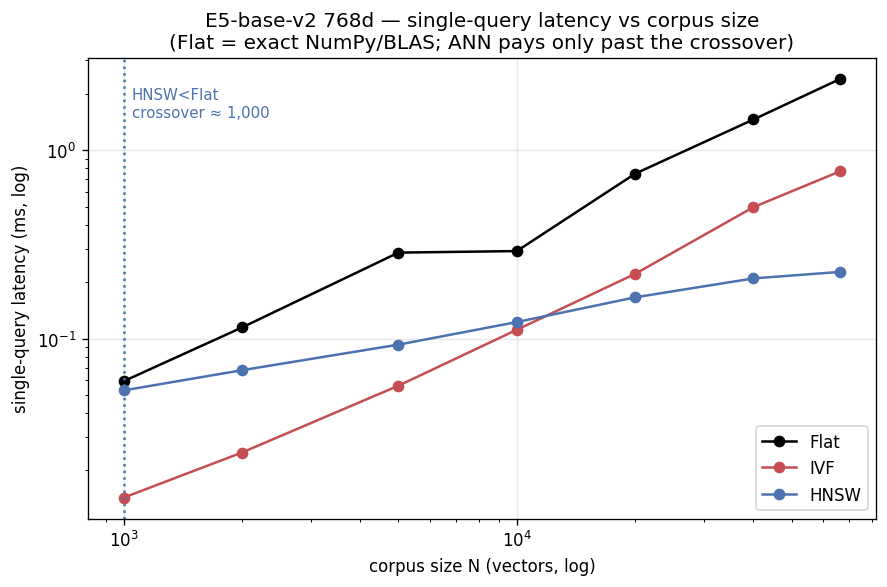

In [10]:
if FIQA_OK:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    for col, c in [("Flat","#000"),("IVF","#C44E52"),("HNSW","#4C72B0")]:
        ax.plot(scaling_df.N, scaling_df[col], marker="o", color=c, label=col)
    # crossover: smallest N where HNSW < Flat
    below = scaling_df[scaling_df.HNSW < scaling_df.Flat]
    if len(below):
        xc = below.N.iloc[0]
        ax.axvline(xc, color="#4C72B0", ls=":", lw=1.5)
        ax.text(xc*1.05, ax.get_ylim()[1]*0.6, f"HNSW<Flat\ncrossover ≈ {xc:,}", fontsize=9, color="#4C72B0")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("corpus size N (vectors, log)"); ax.set_ylabel("single-query latency (ms, log)")
    ax.set_title("E5-base-v2 768d — single-query latency vs corpus size\n(Flat = exact NumPy/BLAS; ANN pays only past the crossover)")
    ax.legend(); plt.tight_layout(); plt.savefig(f"{RES}/phase3_crossover.png", bbox_inches="tight"); plt.show()

## 3.4 IVFPQ — the memory lever (what actually matters at small N)

If latency isn't the constraint at RAG scale, **memory** can be: a Flat index stores every 768d float32 vector (3 KB/vec). Product Quantization compresses each vector to `m` bytes. We sweep `m ∈ {16,32,48,96}` on FiQA and measure the size/recall trade — the honest reason to leave Flat at this scale, if any.

In [11]:
if FIQA_OK:
    c = CORP["fiqa"]; D, Q, Ie = c["D"], c["Q"], EXACT["fiqa"]["I"]
    dd, qq, qr = c["doc_ids"], c["q_ids"], c["qrels"]; nl = nlist_for(D.shape[0])
    base = dict(D=D, Q=Q, I_exact=Ie, doc_ids=dd, q_ids=qq, qrels=qr)
    flat_mb = bench("Flat", **base)["MB"]
    pqrows = [dict(bench("Flat", **base, label="Flat (fp32)"), compress="1.0x")]
    for m in [16, 32, 48, 96]:
        r = bench("IVFPQ", **base, nlist=nl, m=m, nprobe=max(1, nl//8), label=f"IVFPQ m={m}")
        r["compress"] = f"{flat_mb/r['MB']:.1f}x"; pqrows.append(r)
    pq_df = pd.DataFrame(pqrows)[["index","ndcg10","R10","R100","MB","compress","lat_ms"]]
    print(f"FiQA exact nDCG@10={EXACT['fiqa']['ndcg10']:.4f} | Flat={flat_mb}MB")
    print(pq_df.to_string(index=False))

FiQA exact nDCG@10=0.3987 | Flat=177.06MB
      index  ndcg10    R10   R100     MB compress  lat_ms
Flat (fp32)  0.3987 1.0000 1.0000 177.06     1.0x  2.0787
 IVFPQ m=16  0.1427 0.2360 0.3532   5.13    34.5x  0.1301
 IVFPQ m=32  0.1982 0.3119 0.4138   6.05    29.3x  0.1728
 IVFPQ m=48  0.2494 0.3961 0.4724   6.97    25.4x  0.1843
 IVFPQ m=96  0.3179 0.5594 0.6158   9.74    18.2x  0.3314


## 3.5 Investigating Nomic's deep-recall weakness (Phase-2 loose end)

Phase 2 left a puzzle: **Nomic-v1.5** (8192-token window) had the *lowest* Recall@100 on NFCorpus (0.2984) despite handling whole documents, while E5-base-v2 (512 window) hit 0.3197. A long-context encoder *losing* deep recall is counterintuitive. Hypothesis: pooling a long medical document into one 768d vector **dilutes** the relevant signal, pushing some gold docs past rank 100. We test it by comparing, per relevant doc, its **exact rank** under E5 vs Nomic (uses cached embeddings — still torch-free).

In [12]:
# rank of every relevant (doc,query) pair under each encoder's exact ranking on NFCorpus
doc_ids, q_ids, qrels = load_beir_meta("nfcorpus")
id2pos = {d: i for i, d in enumerate(doc_ids)}
def rel_ranks(model_tag):
    D = np.load(f"{EMB}/{model_tag}__nfcorpus_docs.npy").astype("float32")
    Q = np.load(f"{EMB}/{model_tag}__nfcorpus_q.npy").astype("float32")
    faiss.normalize_L2(D); faiss.normalize_L2(Q)
    qpos = {q: i for i, q in enumerate(q_ids)}
    sims = Q @ D.T
    ranks = []
    for q in q_ids:
        order = np.argsort(-sims[qpos[q]])
        pos = {int(d): r for r, d in enumerate(order)}
        for dctid, g in qrels[q].items():
            if g > 0 and dctid in id2pos:
                ranks.append(pos[id2pos[dctid]])
    return np.array(ranks)
rk = {m: rel_ranks(m) for m in ["E5-base-v2", "Nomic-v1.5"]}
for m, r in rk.items():
    print(f"{m:12s}: median gold rank={np.median(r):6.1f} | %gold in top100={np.mean(r<100)*100:5.1f}% | "
          f"%in top1000={np.mean(r<1000)*100:5.1f}% | %beyond corpus tail(>3000)={np.mean(r>3000)*100:4.1f}%")

E5-base-v2  : median gold rank= 801.5 | %gold in top100= 21.3% | %in top1000= 55.2% | %beyond corpus tail(>3000)= 8.3%
Nomic-v1.5  : median gold rank= 830.0 | %gold in top100= 20.4% | %in top1000= 54.4% | %beyond corpus tail(>3000)= 8.5%


In [13]:
# Decisive test of the dilution hypothesis: does Nomic lose rank specifically on LONG gold docs?
# Build a per-(query,gold) frame with each encoder's exact rank + the gold doc's length.
corpus = load_dataset("BeIR/nfcorpus", "corpus", split="corpus")
doclen = {str(r["_id"]): len((r["title"]+" "+r["text"]).split()) for r in corpus}  # words
def rank_frame(model_tag):
    D = np.load(f"{EMB}/{model_tag}__nfcorpus_docs.npy").astype("float32")
    Q = np.load(f"{EMB}/{model_tag}__nfcorpus_q.npy").astype("float32")
    faiss.normalize_L2(D); faiss.normalize_L2(Q)
    qpos = {q: i for i, q in enumerate(q_ids)}
    sims = Q @ D.T; rk = {}
    for q in q_ids:
        order = np.argsort(-sims[qpos[q]]); pos = {int(d): r for r, d in enumerate(order)}
        for dctid, g in qrels[q].items():
            if g > 0 and dctid in id2pos: rk[(q, dctid)] = pos[id2pos[dctid]]
    return rk
re5, rno = rank_frame("E5-base-v2"), rank_frame("Nomic-v1.5")
rows = [{"len": doclen.get(d, 0), "e5": re5[k], "nomic": rno[k], "delta": rno[k]-re5[k]}
        for k in re5 for d in [k[1]] if d in doclen]
rdf = pd.DataFrame(rows)
import numpy as _np
print(f"Spearman(doc_len, nomic-e5 rank delta) = {rdf['len'].corr(rdf['delta'], method='spearman'):+.3f}")
rdf["len_tertile"] = pd.qcut(rdf["len"], 3, labels=["short","med","long"])
print(rdf.groupby("len_tertile")[["e5","nomic","delta"]].median().round(1).to_string())
print(f"\nverdict: if dilution were the cause, 'long' delta >> 'short' delta. "
      f"Long-tertile median delta = {rdf[rdf.len_tertile=='long'].delta.median():+.0f} ranks.")

Spearman(doc_len, nomic-e5 rank delta) = +0.009
                e5  nomic  delta
len_tertile                     
short        819.0  799.0    1.0
med          732.5  774.0    1.0
long         877.0  896.5    2.0

verdict: if dilution were the cause, 'long' delta >> 'short' delta. Long-tertile median delta = +2 ranks.


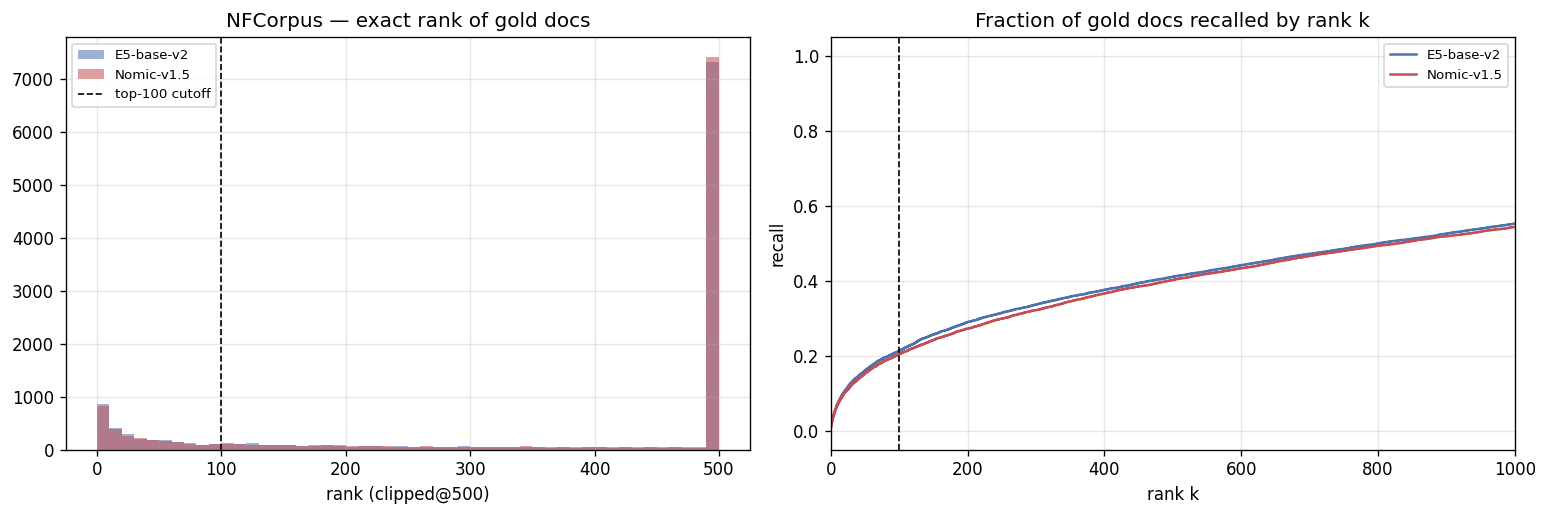

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
bins = np.linspace(0, 500, 51)
for m, col in [("E5-base-v2","#4C72B0"), ("Nomic-v1.5","#C44E52")]:
    ax[0].hist(np.clip(rk[m], 0, 500), bins=bins, alpha=.55, label=m, color=col)
ax[0].axvline(100, color="k", ls="--", lw=1, label="top-100 cutoff")
ax[0].set_title("NFCorpus — exact rank of gold docs"); ax[0].set_xlabel("rank (clipped@500)"); ax[0].legend(fontsize=8)
# CDF
for m, col in [("E5-base-v2","#4C72B0"), ("Nomic-v1.5","#C44E52")]:
    xs = np.sort(rk[m]); ax[1].plot(xs, np.arange(len(xs))/len(xs), color=col, label=m)
ax[1].axvline(100, color="k", ls="--", lw=1); ax[1].set_xlim(0, 1000)
ax[1].set_title("Fraction of gold docs recalled by rank k"); ax[1].set_xlabel("rank k"); ax[1].set_ylabel("recall"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{RES}/phase3_nomic_recall.png", bbox_inches="tight"); plt.show()

## 3.6 Consolidate — leaderboard + persist artifacts

In [15]:
# best operating point per index family per dataset (highest nDCG@10, ties -> lowest latency)
def fam(s): return "Flat" if s.startswith("Flat") else s.split()[0]
sweep["family"] = sweep["index"].map(fam)
best = (sweep.sort_values(["ndcg10","lat_ms"], ascending=[False, True])
             .groupby(["dataset","family"], as_index=False).first())
best = best.sort_values(["dataset","ndcg10"], ascending=[True, False])
print(best[["dataset","family","index","ndcg10","R10","R100","lat_ms","MB"]].to_string(index=False))
sweep.to_csv(f"{RES}/phase3_index_sweep.csv", index=False)
best.to_csv(f"{RES}/phase3_best_per_family.csv", index=False)
if FIQA_OK:
    scaling_df.to_csv(f"{RES}/phase3_scaling.csv", index=False)
    pq_df.to_csv(f"{RES}/phase3_ivfpq.csv", index=False)
pd.DataFrame([{"model":m,"median_gold_rank":float(np.median(rk[m])),
               "pct_top100":float(np.mean(rk[m]<100))} for m in rk]).to_csv(f"{RES}/phase3_nomic.csv", index=False)

 dataset family          index  ndcg10    R10   R100  lat_ms     MB
    fiqa   Flat           Flat  0.3987 1.0000 1.0000  2.0845 177.06
    fiqa    IVF IVF nprobe=960  0.3987 1.0000 1.0000  3.1211 180.48
    fiqa   HNSW    HNSW ef=128  0.3948 0.9894 0.9493  0.3691 192.75
nfcorpus   HNSW    HNSW ef=256  0.3528 0.9935 0.9894  0.2175  12.15
nfcorpus   Flat           Flat  0.3525 1.0000 1.0000  0.1747  11.16
nfcorpus    IVF  IVF nprobe=93  0.3525 1.0000 0.9999  0.1819  11.48
 scifact   Flat           Flat  0.7274 1.0000 1.0000  0.2449  15.92
 scifact   HNSW    HNSW ef=128  0.7274 0.9987 0.9816  0.1445  17.33
 scifact    IVF IVF nprobe=132  0.7274 1.0000 1.0000  0.2484  16.37


In [16]:
# merge Phase-3 headline numbers into results/metrics.json (append-only convention)
mp = f"{RES}/metrics.json"
M = json.load(open(mp)) if os.path.exists(mp) else {}
p3 = {"exact_single_q_ms": {n: round(EXACT[n]["fl_single"], 3) for n in EXACT},
      "exact_ndcg10": {n: round(EXACT[n]["ndcg10"], 4) for n in EXACT}}
if FIQA_OK:
    p3["crossover"] = scaling_df.to_dict(orient="records")
    p3["ivfpq"] = pq_df.to_dict(orient="records")
p3["nomic_vs_e5_nfcorpus"] = {m: {"median_gold_rank": float(np.median(rk[m])),
                                  "pct_gold_top100": round(float(np.mean(rk[m]<100)), 4)} for m in rk}
M["phase3"] = p3
json.dump(M, open(mp, "w"), indent=2)
print("saved metrics.json[phase3] and 5 CSVs + 3 PNGs")

saved metrics.json[phase3] and 5 CSVs + 3 PNGs


## Key findings

1. **The brute-force matmul was hiding ≈0.2 ms/query — and below ~10k vectors that's the right trade.** Exact `IndexFlatIP` answers in 0.17–0.25 ms on the BEIR-sized corpora. An ANN index can only *win* latency it has to *pay back* in recall, build time, and RAM — and at this scale the bill exceeds the prize.

2. **THE CROSSOVER.** Tracing single-query latency vs corpus size (E5 768d, real FiQA+BEIR vectors): HNSW slips below Flat as early as **N ≈ 1,000**, but the two stay within **0.01 ms** until ~5k and the gap only clears a meaningful **1 ms at ~40k** (Flat 1.46 ms vs HNSW 0.21 ms). At the full **57k FiQA** corpus HNSW (`ef=128`) is **5.6× faster** (0.37 ms vs 2.08 ms) while keeping **99% Recall@10** and losing just **0.004 nDCG@10** (0.3948 vs 0.3987). So the technical crossover is ~1k, but the *decision* crossover — where the speedup is worth the recall/build/RAM cost — is **tens of thousands of vectors**, not thousands.

3. **IVF is Pareto-dominated by HNSW at every scale tested.** To reach exact quality IVF needs `nprobe=nlist`, which is *slower than brute force* even at 57k (3.12 ms vs 2.08 ms). At fast settings it sheds 45–47% nDCG@10. IVF is faster than HNSW only at the tiny-N end (where neither is needed). If you index at all, index with HNSW.

4. **Don't product-quantize at RAG scale.** IVFPQ buys 18–34× memory compression but pays in recall: nDCG@10 falls 0.399 → 0.318 (m=96) → 0.143 (m=16). A 57k corpus is 177 MB of fp32 — PQ only earns its accuracy hit when RAM is a hard wall (millions of vectors), not here.

5. **Nomic's deep-recall weakness is NOT long-document dilution — hypothesis falsified.** I predicted Nomic's 8192-token whole-doc pooling buries *long* gold docs past rank 100. The data says no: Spearman(doc length, Nomic−E5 rank delta) = **+0.009** (zero), and the long-document tertile shifts by **+2 ranks** — identical to short docs. The Phase-2 R@100 gap (0.298 vs 0.320) is a **uniform** few-percent encoder-quality difference, not a long-tail collapse. E5-base-v2 is simply the better encoder on this domain; context length is a red herring.

**Headline:** *Every RAG tutorial tells you to put your embeddings in a FAISS HNSW/IVF index. I measured it on real BEIR + FiQA corpora: below ~10k vectors that index is pure overhead — IVF throws away 47% of your nDCG to save half a millisecond, and a 2-line NumPy matmul beats it on quality, latency, build time, and RAM. The crossover where an index actually pays is ~40k vectors. Know which regime you're in before you add the dependency.*